In [10]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random

In [11]:
market = ADatabase("market")

In [12]:
queries = []
for band in [10,15,30,100]:
    for holding_period in [1,5,10,15,30]:
        queries.append({"band":band,"holding_period":holding_period})

In [23]:
for query in tqdm(queries):
    band = query["band"]
    hpr = query["holding_period"]
    market.connect()
    df = market.retrieve("crypto")
    market.disconnect()
    df["date"] = [datetime.utcfromtimestamp(int(x)) for x in df["start"]]
    df.sort_values("date",inplace=True)
    df["close"] = [float(x) for x in df["close"]]
    df["return"] = df["close"].pct_change()
    df["rolling"] = df["close"].rolling(band).mean()
    df["signal"] = df["rolling"] > df["close"]
    df["signal"] = [1 if x == True else - 1 for x in df["signal"]]
    df["buy_price"] = df["close"]
    df["sell_price"] = df["close"].shift(-hpr)
    portfolios = df[::hpr].copy().dropna()
    portfolios.sort_values("date",inplace=True)
    portfolios["return"] = (portfolios["sell_price"] - portfolios["buy_price"]) / portfolios["buy_price"] * portfolios["signal"] + 1
    # portfolios["return"] = [max(x,-stoploss*leverage+1) for x in portfolios["return"]]
    portfolios["cr"] = portfolios["return"].cumprod() * 100
    query["cr"] = portfolios["cr"].iloc[-1]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:46<00:00,  2.31s/it]


In [24]:
portfolios["return"].min()

0.9369140474358909

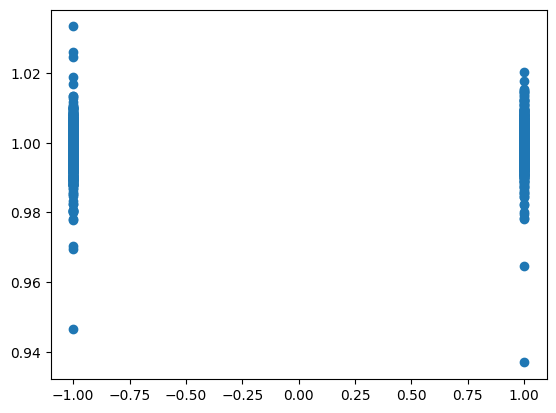

In [25]:
plt.scatter(portfolios["signal"],portfolios["return"])
plt.show()

In [26]:
pd.DataFrame(queries).sort_values("cr",ascending=False)

,band,holding_period,cr
3,10,15,214.753038
8,15,15,193.695457
1,10,5,170.015600
9,15,30,153.266553
14,30,30,148.157260
7,15,10,147.914709
13,30,15,147.606725
0,10,1,146.204649
11,30,5,145.208225
6,15,5,143.612878


In [27]:
trades = portfolios[portfolios["return"]!=1]
trades

,start,low,high,open,close,volume,ticker,date,return,rolling,signal,buy_price,sell_price,cr
230244,1694680620,26326.83,26332.39,26332.39,26329.75,2.44977258,BTC-USD,2023-09-14 08:37:00,1.001302,26313.1326,-1,26329.75,26295.48,100.130157
230214,1694682420,26292.27,26298.14,26297.2,26295.48,1.74161455,BTC-USD,2023-09-14 09:07:00,0.999227,26322.0273,1,26295.48,26275.16,100.052781
230184,1694684220,26274.05,26281.32,26278.11,26275.16,1.8651055,BTC-USD,2023-09-14 09:37:00,1.000730,26311.3315,1,26275.16,26294.34,100.125816
230154,1694686020,26289.53,26295.26,26290.03,26294.34,0.72956767,BTC-USD,2023-09-14 10:07:00,1.000245,26294.4694,1,26294.34,26300.78,100.150339
230124,1694687820,26293.32,26317.88,26317.88,26300.78,33.23621809,BTC-USD,2023-09-14 10:37:00,0.998129,26295.0385,-1,26300.78,26349.99,99.962953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,1708486560,52044.34,52070.99,52058.59,52065.45,3.30502768,BTC-USD,2024-02-21 03:36:00,0.999212,52096.0334,1,52065.45,52024.44,90.577649
144,1708488360,52020.72,52026.37,52024.12,52024.44,1.7216123,BTC-USD,2024-02-21 04:06:00,0.996524,52074.2325,1,52024.44,51843.60,90.262795
114,1708490160,51840.64,51878.41,51873.27,51843.60,2.54482926,BTC-USD,2024-02-21 04:36:00,1.005488,52032.1044,1,51843.60,52128.10,90.758127
84,1708491960,52079.77,52131.35,52100.46,52128.10,4.51213492,BTC-USD,2024-02-21 05:06:00,1.004473,52005.2862,-1,52128.10,51894.93,91.164090
